In [138]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [139]:
from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala import graph_utils as gu
from koala import plotting as pl
from koala.lattice import Lattice, INVALID
from koala import example_graphs as eg
from koala import pachner_moves
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

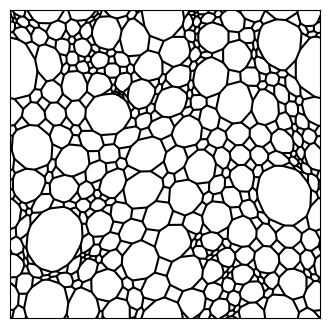

In [140]:
# generate a bipartite lattice
n_sites = 1000

lattice = generate_lattice(uniform(n_sites // 4))
dimerisation = gu.dimerise(lattice)
initial_lattice = gu.dimer_collapse(lattice, dimerisation)
initial_lattice = gu.vertices_to_polygon(initial_lattice)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
pl.plot_edges(initial_lattice)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [ ]:
def lattice_squenergy(lattice):
    return np.sum([p.n_sides == 4 for p in lattice.plaquettes])


def plus_change_squenergy(lattice: Lattice, plaquette: int, central_vertex: int):

    plaq = lattice.plaquettes[plaquette]
    assert plaq.n_sides > 4, "You cant contract a square"
    assert central_vertex in plaq.vertices, "The vertex must be on the plaquette given"

    _ = np.where(plaq.vertices == central_vertex)[0][0]
    edges_around = plaq.edges[np.arange(_ - 2, _ + 2) % plaq.n_sides]

    plaqs_to_check = np.array(
        [
            lattice.edges.adjacent_plaquettes[a]
            for a in [edges_around[0], edges_around[3]]
        ]
    ).flatten()

    p, c = np.unique(plaqs_to_check, return_counts=True)

    sides_relevant = np.array([lattice.plaquettes[i].n_sides for i in p])
    new_sides = sides_relevant + 2
    new_sides[np.where(c == 2)] -= 4

    n_squares_before = np.sum(sides_relevant == 4)
    n_squares_after = np.sum(new_sides == 4) + 1
    return int(n_squares_after - n_squares_before)


def minus_change_squenergy(lattice: Lattice, edge: int):

    side_plaqs = lattice.edges.adjacent_plaquettes[edge]
    vertices = lattice.edges.indices[edge]
    plaqs = np.unique(lattice.vertices.adjacent_plaquettes[vertices].flatten())
    corner_plaqs = np.array(list(set(plaqs) - set(side_plaqs)))

    side_sides = np.array([lattice.plaquettes[x].n_sides for x in side_plaqs])
    corner_sides = np.array([lattice.plaquettes[x].n_sides for x in corner_plaqs])

    sides_after = side_sides - 2
    corner_after = np.sum(corner_sides) - 2

    n_squares_before = np.sum(side_sides == 4) + np.sum(corner_sides == 4)
    n_squares_after = np.sum(sides_after == 4) + (corner_after == 4)

    return int(n_squares_after - n_squares_before)


def find_plus_candidate(lattice: Lattice, rng=np.random.default_rng()):
    candidate = None
    while candidate is None:
        plaq = rng.choice(len(lattice.plaquettes))
        vertex = int(rng.choice(lattice.plaquettes[plaq].vertices))
        c1 = lattice.plaquettes[plaq].n_sides > 4

        adj_plaqs = lattice.vertices.adjacent_plaquettes[vertex]
        c2 = np.sum([lattice.plaquettes[i].n_sides == 4 for i in adj_plaqs]) <= 1

        if c1 and c2:
            candidate = (plaq, vertex)

    return (plaq, vertex)


def find_minus_candidate(lattice: Lattice, rng=np.random.default_rng()):
    candidate = None
    while candidate is None:
        plaq = rng.choice(len(lattice.plaquettes))
        if lattice.plaquettes[plaq].n_sides != 4:
            continue
        chosen_vertex = rng.choice(lattice.plaquettes[plaq].vertices)
        edges_out = lattice.vertices.adjacent_edges[chosen_vertex]
        chosen_edge = list(set(edges_out) - set(lattice.plaquettes[plaq].edges))[0]

        cond = [
            lattice.plaquettes[i].n_sides == 4
            for i in lattice.edges.adjacent_plaquettes[chosen_edge]
        ]
        if np.sum(cond) == 0:
            candidate = chosen_edge

    return (candidate,)


def boltzmann_probability(delta_energy, beta):
    return np.exp(-delta_energy * beta)


def choose_flip(n_each_flip, f_range=10):
    diff = (n_each_flip["plus"] - n_each_flip["minus"]) / f_range + 0.5
    p = np.random.rand()
    if p > diff:
        return (
            find_plus_candidate,
            plus_change_squenergy,
            pachner_moves.bipartite_1_plus,
            "plus",
        )
    else:
        return (
            find_minus_candidate,
            minus_change_squenergy,
            pachner_moves.bipartite_1_minus,
            "minus",
        )


def plaq_relax(lattice: Lattice, n_steps: int = 10):
    for _ in range(n_steps):
        for plaq in lattice.plaquettes:
            if plaq.n_sides == 4:
                continue
            vertex = plaq.vertices[0]
            pachner_moves.bipartite_1_plus(lattice, plaq.index, vertex)

In [142]:
import copy

from matplotlib.pylab import f
from numpy import flip
from tqdm import tqdm, trange

# use simulated annealing to find a lattice with as few squares as possible


k_steps = 10000
lattice = copy.copy(initial_lattice)
n_each_flip = {"plus": 0, "minus": 0}
beta_range = np.linspace(1, 100, k_steps)
rng = np.random.default_rng(4)
all_lattices = []
energies = []
total_plaqs = []

tr = trange(k_steps)
for k in tr:

    beta = beta_range[k]  # set inverse temperature
    accept = False
    while not accept:

        # propose a flip move
        cand, change_energy, move, flip_type = choose_flip(n_each_flip)
        candidate = cand(lattice)

        # check energy
        delta_energy = change_energy(lattice, *candidate)
        p = boltzmann_probability(delta_energy, beta)

        if rng.random() < p:
            new_lattice = move(lattice, *candidate)
            new_lattice = gu.toric_tutte_embedding(new_lattice)

            if new_lattice.n_plaquettes == new_lattice.n_vertices // 2:
                accept = True
            else:
                print(f"rejected: {candidate}")

    energy = lattice_squenergy(new_lattice)

    tr.set_description(f"Proportion: {energy/new_lattice.n_plaquettes:.3f}")
    lattice = new_lattice
    n_each_flip[flip_type] += 1
    energies.append(energy)
    all_lattices.append(copy.copy(new_lattice))
    total_plaqs.append(new_lattice.n_plaquettes)

    if energy == 0:
        print("Found a lattice with no squares!")
        break

Proportion: 0.071:  29%|██▉       | 2875/10000 [12:59<32:11,  3.69it/s] 


KeyboardInterrupt: 

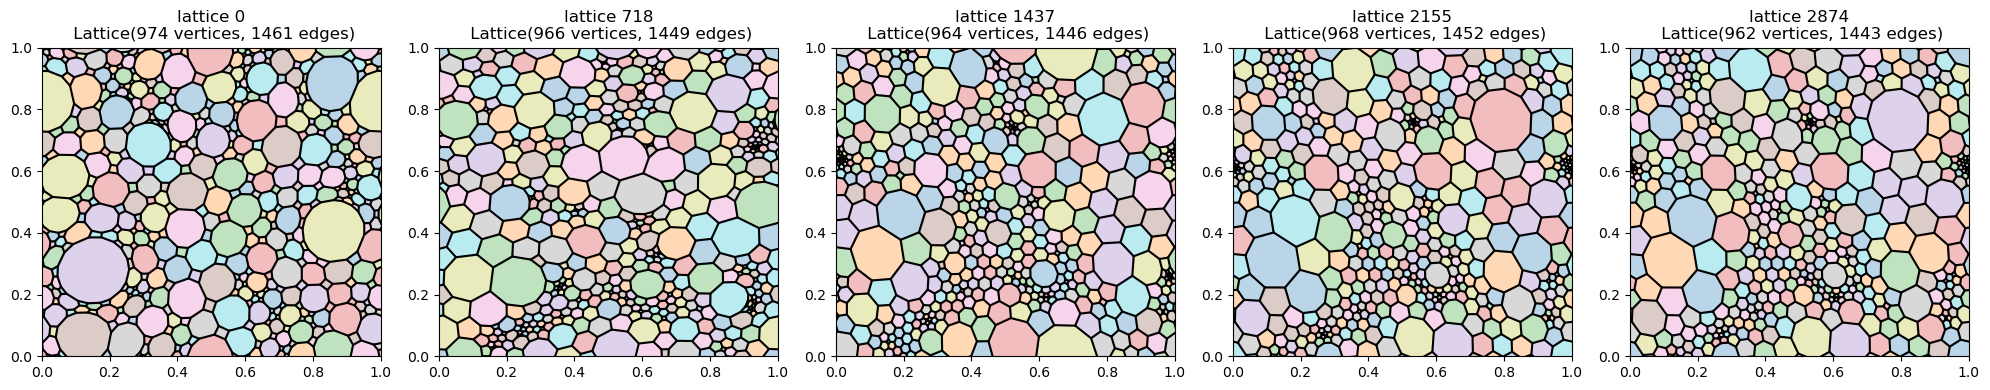

In [ ]:
# %matplotlib inline
# %matplotlib widget
scale = 4

n = 5
lattices_to_show = np.linspace(0, len(all_lattices) - 1, n, dtype=int)

fig, ax = plt.subplots(1, n, figsize=(n * scale, scale))

for j, l_index in enumerate(lattices_to_show):

    lat_show = all_lattices[l_index]

    cmap = plt.get_cmap("tab10")
    plaq_labels = np.arange(lat_show.n_plaquettes)
    color_scheme = cmap(plaq_labels % 10)

    #     # pl.plot_vertex_indices(all_lattices[-n + j], ax=ax[j],offset = 0)
    #     # pl.plot_edge_indices(all_lattices[-n + j], ax=ax[j], offset=0)
    pl.plot_edges(lat_show, ax=ax[j])
    pl.plot_plaquettes(
        lat_show,
        ax=ax[j],
        labels=plaq_labels,
        color_scheme=color_scheme,
        alpha=0.3,
    )
    ax[j].set_title(f"lattice {l_index}\n {lat_show}")
plt.tight_layout()
plt.savefig("pachner_metropolis.png", dpi=300)
plt.show()

{'plus': 1435, 'minus': 1440}


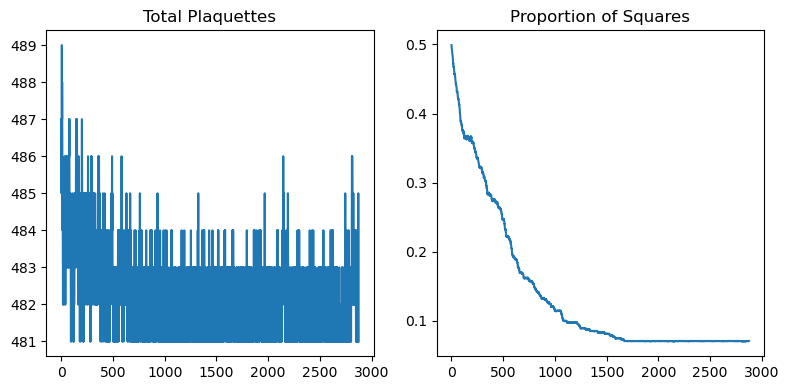

In [144]:
proportion_squares = np.array(energies) / np.array(total_plaqs)
print(n_each_flip)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].plot(total_plaqs)
ax[1].plot(proportion_squares)

ax[0].set_title("Total Plaquettes")
ax[1].set_title("Proportion of Squares")
plt.tight_layout()
plt.savefig("pachner_metropolis_energy.png", dpi=300)